# Deteccion de Caracteristicas

In [ ]:
#Importar Librerias

import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import glob

#Crear los detectores

akaze = cv2.AKAZE_create()
orb = cv2.ORB_create()

# Agregar las Imagenes

In [ ]:
notebook_dir = os.getcwd()
project_dir = os.path.dirname(notebook_dir)
image_folder = os.path.join(project_dir)
image_files = glob.glob(os.path.join(image_folder, 'data', 'original', '*.jpg'))

if not image_files:
        print("No se encontraron imagenes.", image_folder)

# Detector Orb

In [ ]:
def Orb_Detector():

    num_images = len(image_files)
    plt.figure(figsize=(5 * num_images, 5))

    for i, image in enumerate(image_files):
        img = cv2.imread(image)
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        kp_orb, des_orb = orb.detectAndCompute(img_gray, None)
        img_orb = cv2.drawKeypoints(img, kp_orb, None, color=(0,255,0), flags=0)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(cv2.cvtColor(img_orb, cv2.COLOR_BGR2RGB))
        plt.title(f"ORB detecto - {len(kp_orb)} puntos")
        plt.axis('off')
    plt.suptitle("Orb")
    plt.show()


# Detector Akaze

In [ ]:
def Akaze_Detector():

    num_images = len(image_files)
    plt.figure(figsize=(5 * num_images, 5))

    for i, image in enumerate(image_files):
        img = cv2.imread(image)
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        kp_akaze, des_akaze = akaze.detectAndCompute(img_gray, None)
        img_akaze = cv2.drawKeypoints(img, kp_akaze, None, color=(0,255,0), flags=0)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(cv2.cvtColor(img_akaze, cv2.COLOR_BGR2RGB))
        plt.title(f"Akaze detecto - {len(kp_akaze)} puntos")
        plt.axis('off')
    plt.suptitle("Akaze")
    plt.show()

# Ejecutamos los Detectores

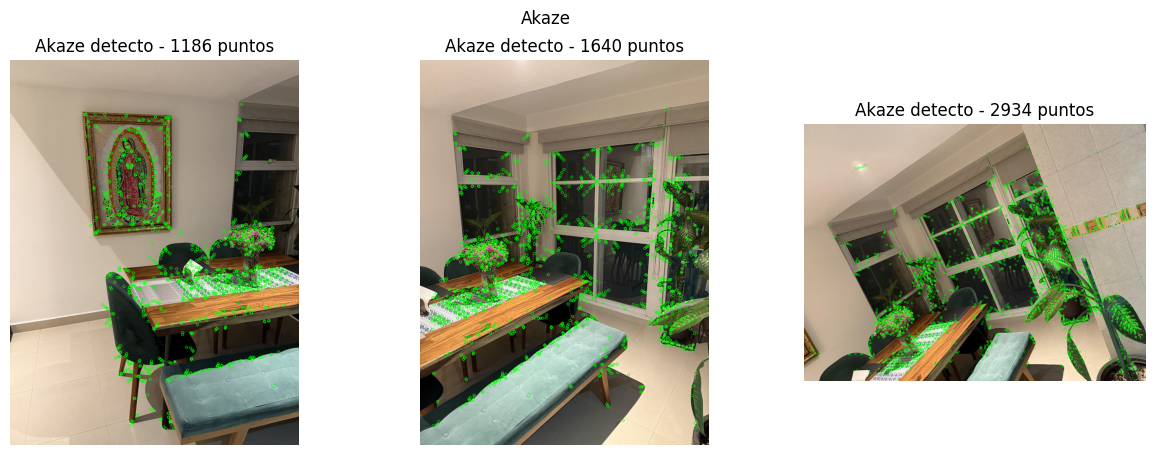

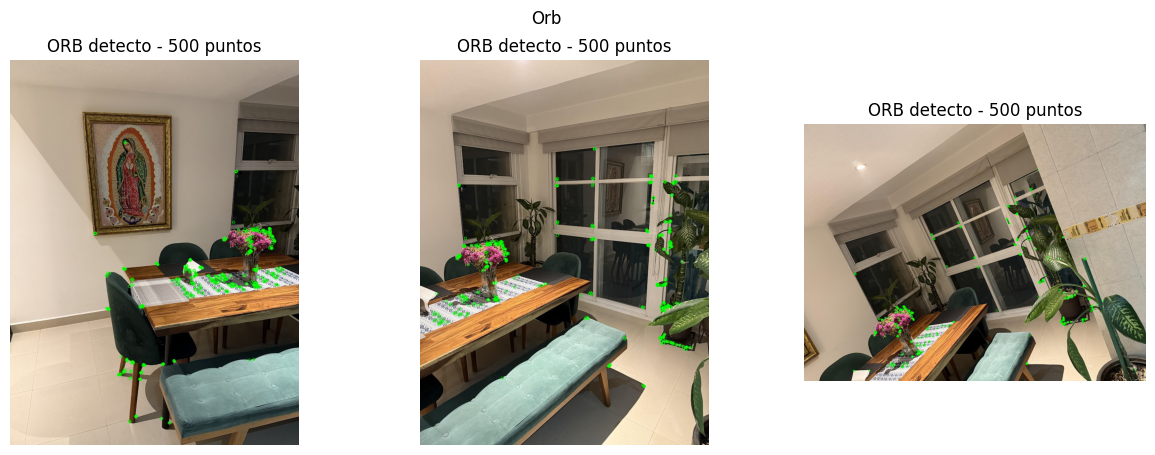

In [ ]:
img1 = cv2.imread(image_files[0])
img2 = cv2.imread(image_files[1])
img3 = cv2.imread(image_files[2])

# Llamamos los detectores
Akaze_Detector()
Orb_Detector()

# Emparejamiento

def Emparejamiento(image1, image2, detector, detector_txt):

    # Detectar keypoints y descriptores
    kp1, des1 = detector.detectAndCompute(image1, None)
    kp2, des2 = detector.detectAndCompute(image2, None)

    if des1 is None or des2 is None:
        print("No se detectaron suficientes características en una de las imágenes")
        return None, None, None, None

    # Matcher
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    matches = bf.knnMatch(des1, des2, k=2)

    # Lowe's Ratio Test
    good_matches = []
    for m_n in matches:
        if len(m_n) == 2:
            m, n = m_n
            if m.distance < 0.8 * n.distance:
                good_matches.append(m)

    print(f"[{detector_txt}] Características detectadas: {len(kp1)} en img1, {len(kp2)} en img2")
    print(f"[{detector_txt}] Matches buenos: {len(good_matches)}")

    if len(good_matches) < 4:
        print(f"[{detector_txt}] Insuficientes matches para calcular homografía")
        return None, None, None, None

    # Extraer puntos
    pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches])

    # Calcular Homografía con RANSAC
    H, mask = cv2.findHomography(pts1, pts2, cv2.RANSAC, 5.0)
    inliers = mask.ravel().tolist() if mask is not None else []
    print(f"[{detector_txt}] Inliers (RANSAC): {sum(inliers)}/{len(inliers)}")

    # Dibujar matches
    img_matches = cv2.drawMatches(
        image1, kp1, image2, kp2, good_matches, None,
        matchesMask=inliers, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    return H, pts1, pts2, img_matches

# Logica Emparejamiento

[ORB] Características detectadas: 500 en img1, 500 en img2
[ORB] Matches buenos: 99
[ORB] Inliers (RANSAC): 87/99
[AKAZE] Características detectadas: 1186 en img1, 1640 en img2
[AKAZE] Matches buenos: 324
[AKAZE] Inliers (RANSAC): 258/324
[ORB] Características detectadas: 500 en img1, 500 en img2
[ORB] Matches buenos: 49
[ORB] Inliers (RANSAC): 39/49
[AKAZE] Características detectadas: 1186 en img1, 2934 en img2
[AKAZE] Matches buenos: 145
[AKAZE] Inliers (RANSAC): 73/145


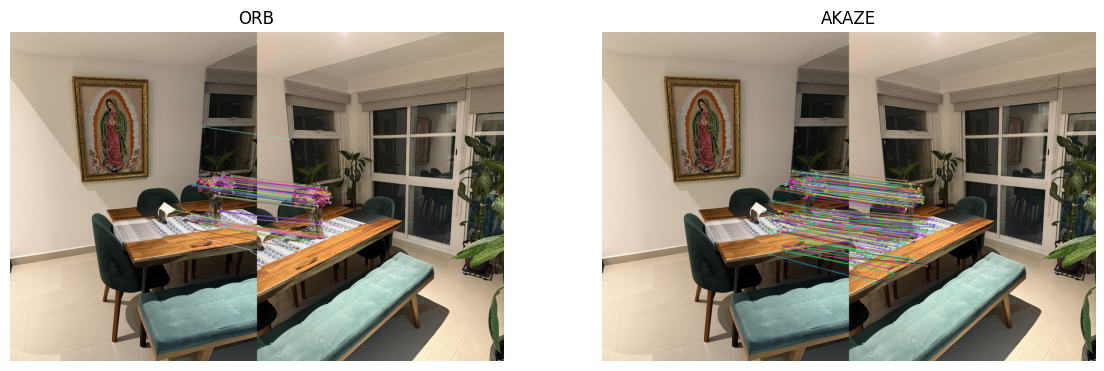

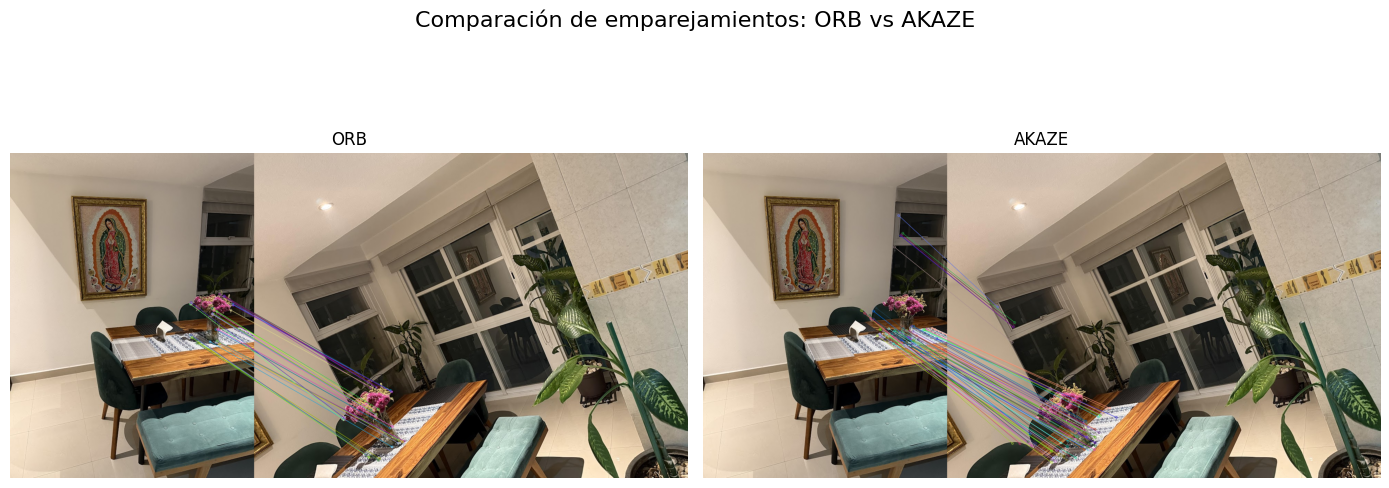

In [ ]:
#Dibujamos los Matches

ref_img = cv2.imread(image_files[0])

for i, img in enumerate(image_files[1:], start=1):

    img = cv2.imread(img)

    # ORB
    H_orb, prs1Orb, pts2Orb, img_match_orb = Emparejamiento(ref_img, img, orb, "ORB")

    # AKAZE
    H_akaze, prs1Ak, pts2Ak, img_match_akaze = Emparejamiento(ref_img, img, akaze, "AKAZE")

    plt.figure(figsize=(14, 6))

    if img_match_orb is not None:
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(img_match_orb, cv2.COLOR_BGR2RGB))
        plt.title(f"ORB")
        plt.axis('off')

    if img_match_akaze is not None:
        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(img_match_akaze, cv2.COLOR_BGR2RGB))
        plt.title(f"AKAZE")
        plt.axis('off')
plt.suptitle("Comparación de emparejamientos: ORB vs AKAZE", fontsize=16)
plt.tight_layout()
plt.show()

# Combinar las tres imagenes

In [ ]:
def bundle(H, pts_src, pts_dst, type="ORB"):
    try:
        # Recalcular homografía optimizada con método de reproyección robusto
        H_opt, _ = cv2.findHomography(pts_src, pts_dst, cv2.RANSAC, 3.0)
        print(f"Optimización de homografía completada para {type}")
        return H_opt if H_opt is not None else H
    except Exception as e:
        print(f"Error en la optimización de homografía ({type}): {e}")
        return H

[ORB] Características detectadas: 500 en img1, 500 en img2
[ORB] Matches buenos: 99
[ORB] Inliers (RANSAC): 87/99
Optimización de homografía completada para ORB


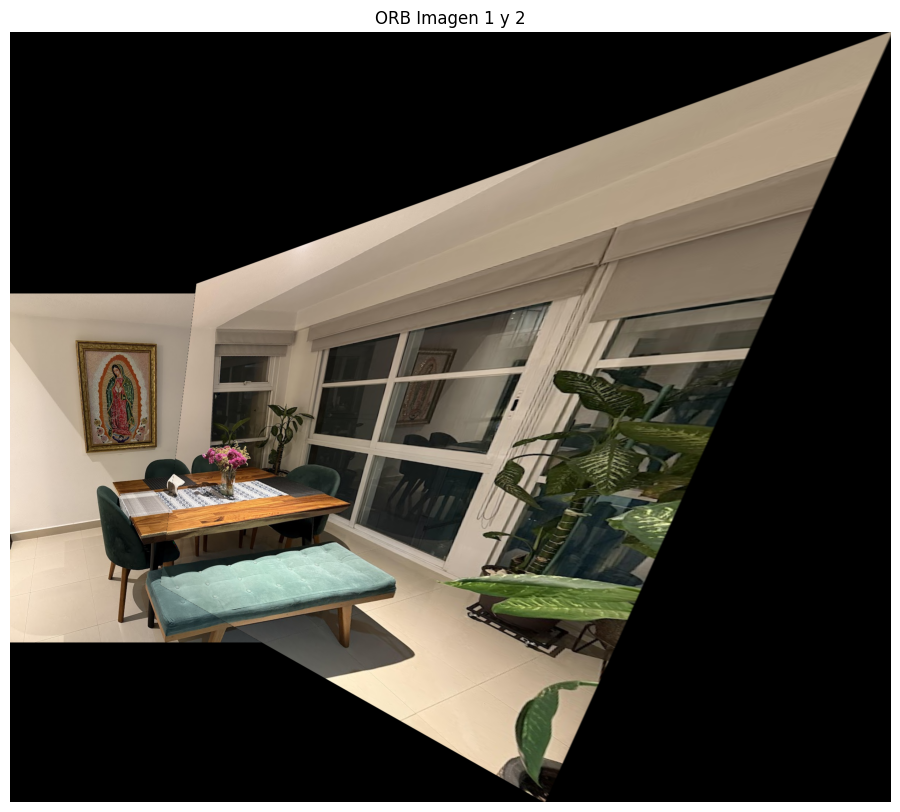

[ORB] Características detectadas: 500 en img1, 500 en img2
[ORB] Matches buenos: 111
[ORB] Inliers (RANSAC): 65/111
Optimización de homografía completada para ORB


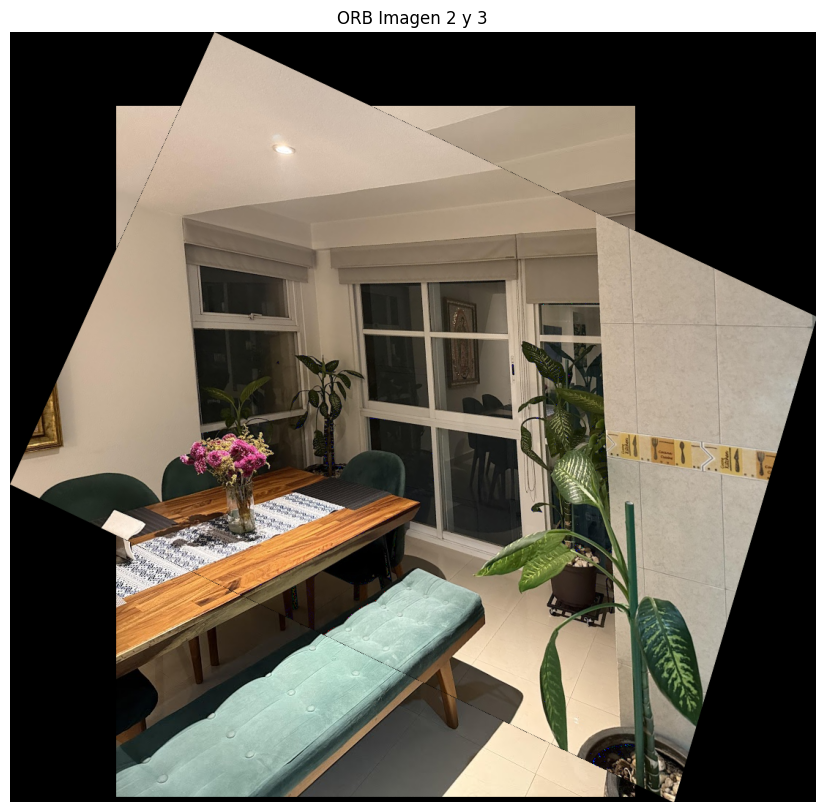

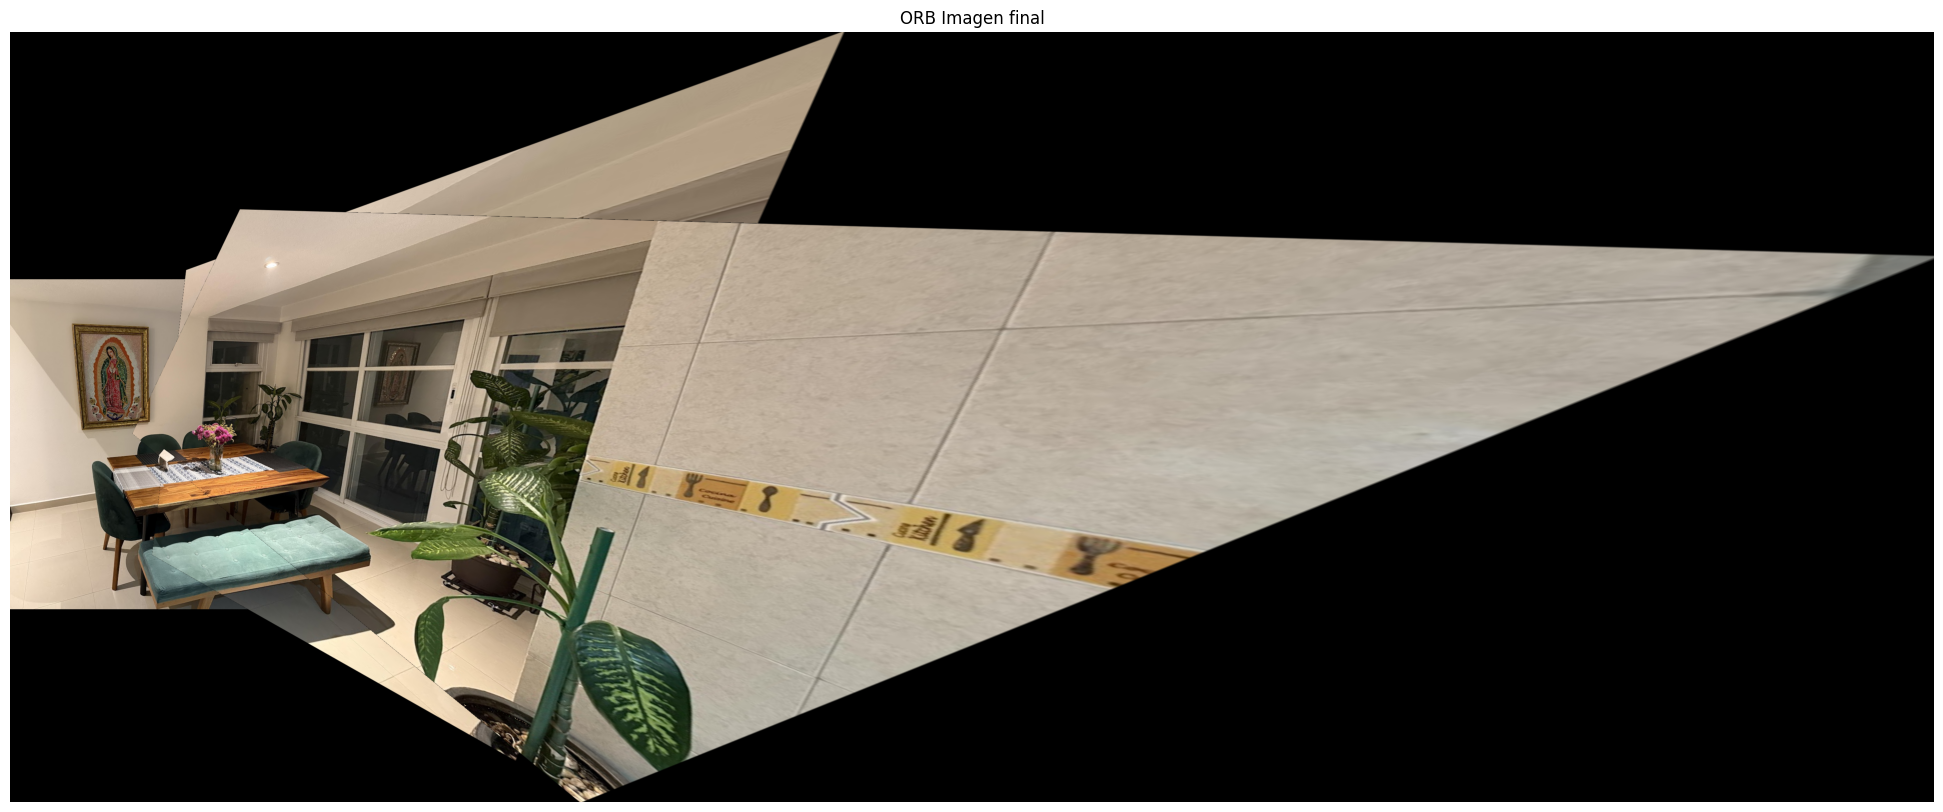

[AKAZE] Características detectadas: 1186 en img1, 1640 en img2
[AKAZE] Matches buenos: 324
[AKAZE] Inliers (RANSAC): 258/324
Optimización de homografía completada para AKAZE


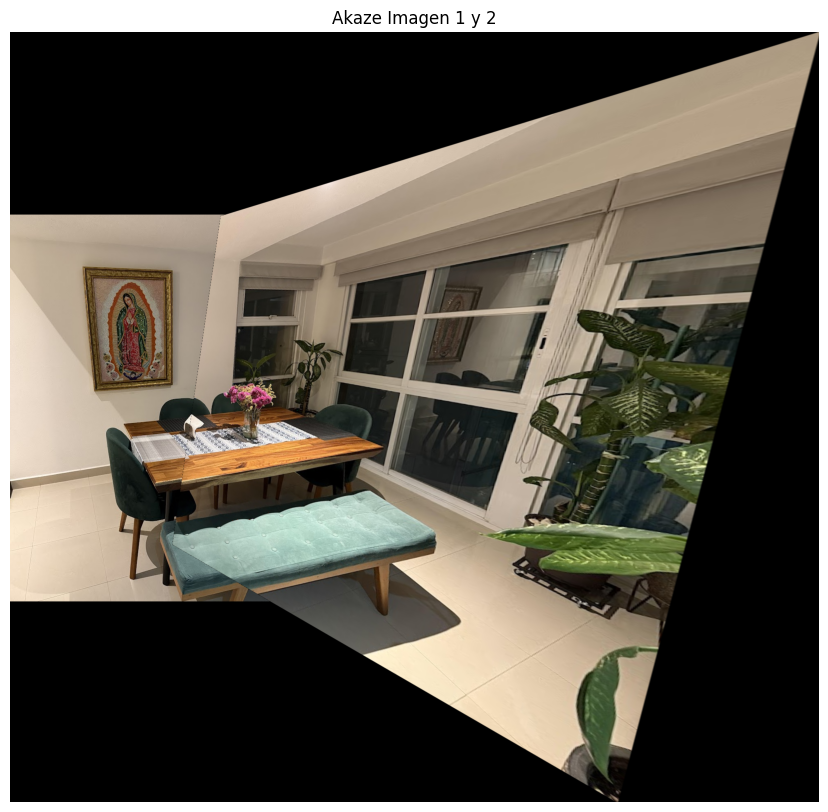

[AKAZE] Características detectadas: 1640 en img1, 2934 en img2
[AKAZE] Matches buenos: 509
[AKAZE] Inliers (RANSAC): 185/509
Optimización de homografía completada para AKAZE


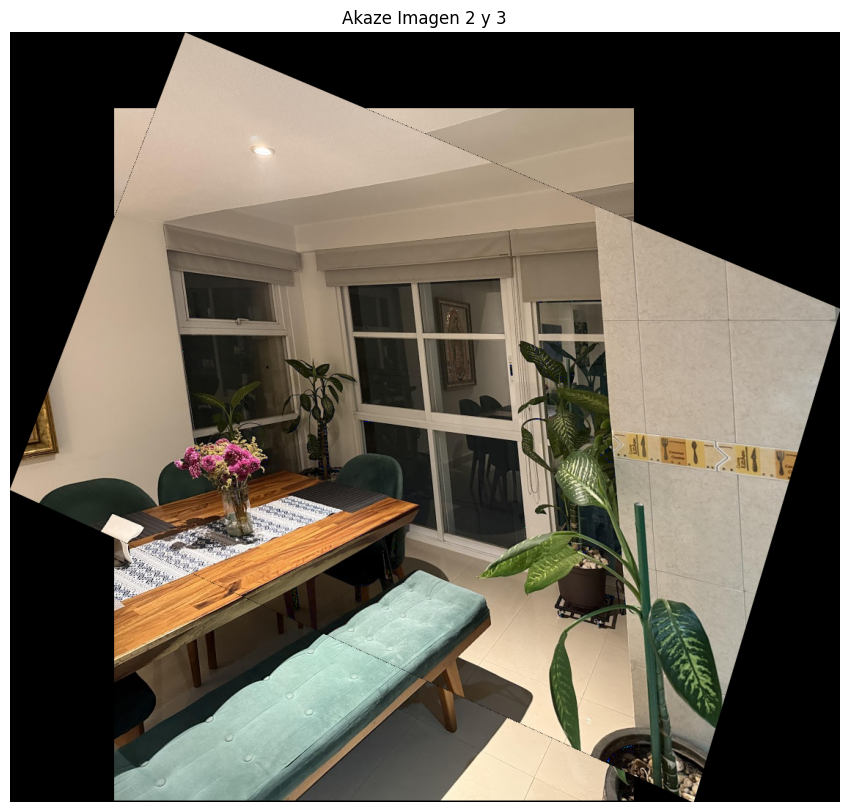

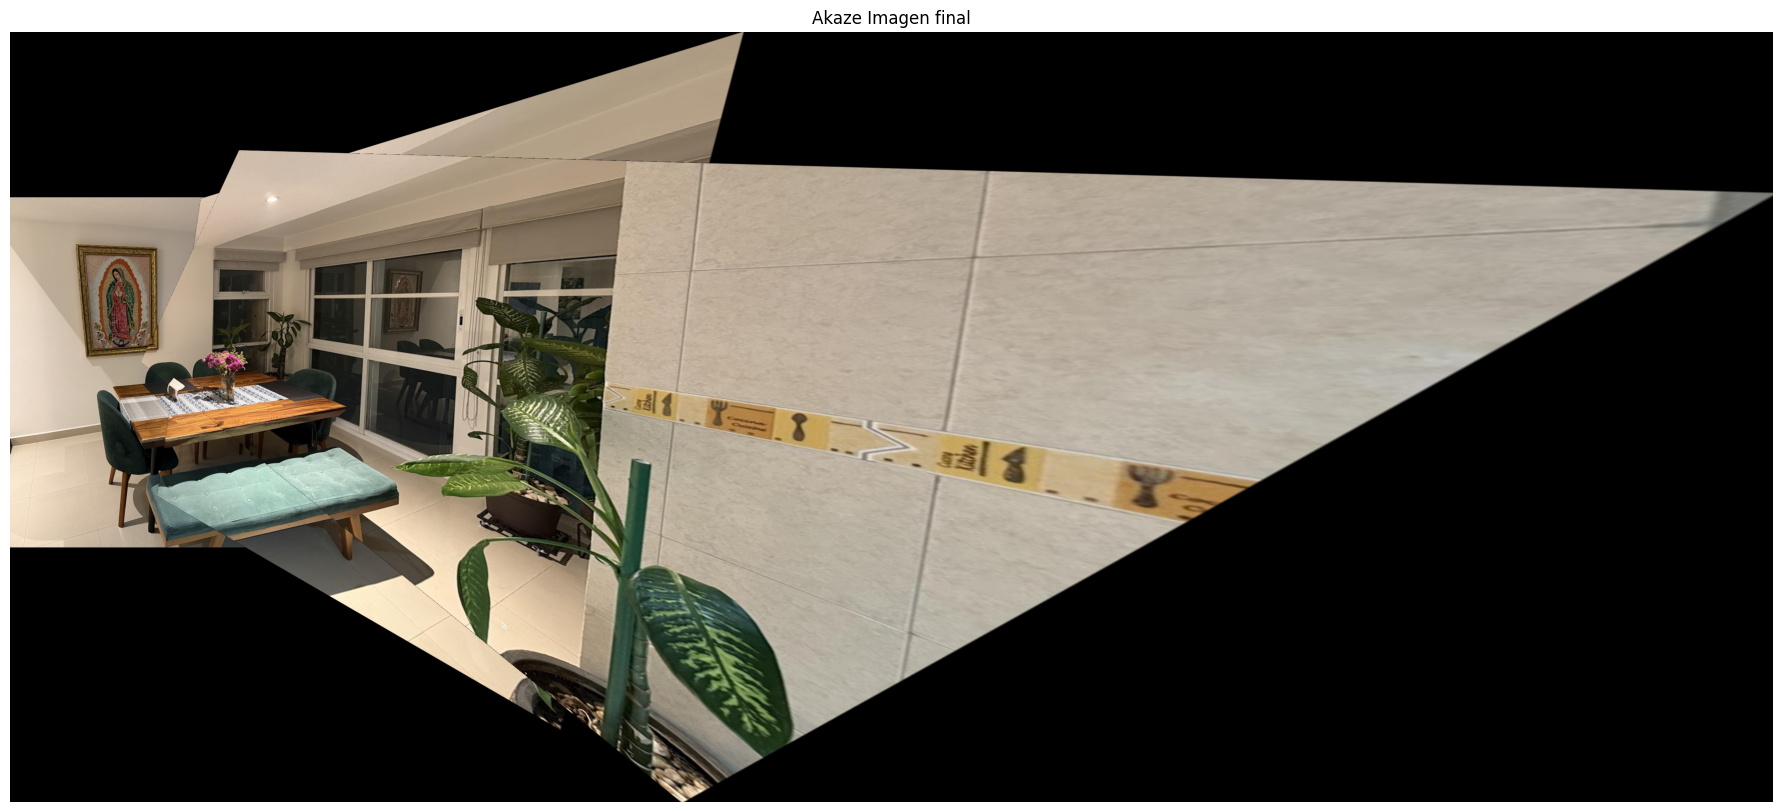

-1

In [ ]:
def align_and_blend_mask(img1, img2, type, detector, alpha=0.5):

    # Escalar al mismo alto
    h_target = min(img1.shape[0], img2.shape[0])
    scale1 = h_target / img1.shape[0]
    scale2 = h_target / img2.shape[0]

    img1_scaled = cv2.resize(img1, (int(img1.shape[1] * scale1), h_target))
    img2_scaled = cv2.resize(img2, (int(img2.shape[1] * scale2), h_target))

    # Emparejamiento
    H, pts1, pts2, matches_img = Emparejamiento(img1_scaled, img2_scaled, type, detector)

    # Bunddle
    H = bundle(H, pts1, pts2, detector)

    # Invertimos la Homografia
    retval, H = cv2.invert(H)

    # Expandir canvas si es necesario
    h1, w1 = img1_scaled.shape[:2]
    h2, w2 = img2_scaled.shape[:2]

    canvas_w = max(w1, w2 + abs(int(H[0,2])))
    canvas_h = max(h1, h2 + abs(int(H[1,2])))

    canvas = np.ones((canvas_h, canvas_w, 3), dtype=np.uint8) * 255
    canvas[0:h1, 0:w1] = img1_scaled

    # warp  la segunda imagen sobre el canvas nuevo
    img2_warped = cv2.warpPerspective(img2_scaled, H, (canvas_w, canvas_h))

    # Blend
    result = cv2.addWeighted(canvas, alpha, img2_warped, alpha, 0)

    return result, H, matches_img

def image_Merge(img1, img2, h_detector):
    h_m, w_m = img2.shape[:2]
    h_f, w_f = img1.shape[:2]

    # Esquinas de la imagen FIJA (en su propio sistema de coordenadas)
    corners_fija = np.float32([[0, 0], [0, h_f - 1], [w_f - 1, h_f - 1], [w_f - 1, 0]]).reshape(-1, 1, 2)

    # Esquinas de la imagen MÓVIL (en su propio sistema)
    corners_movil = np.float32([[0, 0], [0, h_m - 1], [w_m - 1, h_m - 1], [w_m - 1, 0]]).reshape(-1, 1, 2)
    # Usamos H para ver dónde "aterrizan" las esquinas de la imagen móvil en la fija
    corners_movil_trans = cv2.perspectiveTransform(corners_movil, h_detector)

    # Cálculo de los límites del nuevo lienzo:
    # Juntamos todas las esquinas (las 4 de la fija y las 4 transformadas de la móvil)
    all_corners = np.concatenate((corners_fija, corners_movil_trans), axis=0)

    # Encontramos los valores X e Y mínimos y máximos de todas las esquinas
    [x_min, y_min] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [x_max, y_max] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    # Calculamos el desplazamiento (traslación) necesario
    # Si x_min es -100, queremos mover todo 100 píxeles a la derecha
    t_x = -x_min
    t_y = -y_min

    # Calculamos el nuevo tamaño del lienzo
    new_w = x_max - x_min
    new_h = y_max - y_min

    # Crear la matriz de Traslación T para el desplazamiento
    # # adicional de la imagen móvil
    # Esta matriz mueve todo el sistema para que quepa en el lienzo
    T = np.array([[1, 0, t_x],[0, 1, t_y],[0, 0, 1]], dtype=np.float32)

    # Deformamos la imagen MÓVIL usando la homografía Y la traslación
    # T.dot(H) aplica H primero, y luego T
    h_merge = T.dot(h_detector)
    movil_print = cv2.warpPerspective(img2, h_merge, (new_w, new_h))

    # Deformamos la imagen FIJA usando SÓLO la traslación
    # (La movemos a su nueva posición en el lienzo grande)
    lienzo_fijo = cv2.warpPerspective(img1, T, (new_w, new_h))

    # Crea el resultado final
    result = lienzo_fijo.copy()

    # Crea una máscara de la imagen móvil deformada (donde no es negro)
    gray_movil_warped = movil_print.copy()
    _, mask_movil = cv2.threshold(gray_movil_warped, 0, 255, cv2.THRESH_BINARY)

    # Pega la imagen móvil en el resultado usando la máscara
    result[mask_movil > 0] = movil_print[mask_movil > 0]

    return result

def merge_three_images(h1, h2):
    images = [img1, img2, img3]

    # H para img1 es la identidad (no hay transformación, está en su propio sistema)
    homographies = [np.identity(3, dtype=np.float32), h1, h2]

    # Calcular el lienzo final (Canvas) a partir de los 3 conjuntos de esquinas
    all_corners = []
    for img, h_accumulated in zip(images, homographies):
       h, w = img.shape[:2]
       corners = np.float32([[0, 0], [0, h - 1], [w - 1, h - 1], [w - 1, 0]]).reshape(-1, 1, 2)
       corners_trans = cv2.perspectiveTransform(corners, h_accumulated)
       all_corners.append(corners_trans)

    all_corners = np.concatenate(all_corners, axis=0)
    [x_min, y_min] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [x_max, y_max] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    # Matriz de Traslación T para que el rincón (x_min, y_min) se mueva a (0, 0)
    t_x = -x_min
    t_y = -y_min
    new_w = x_max - x_min
    new_h = y_max - y_min
    T = np.array([[1, 0, t_x], [0, 1, t_y], [0, 0, 1]], dtype=np.float32)

    final_result = np.zeros((new_h, new_w, 3), dtype=np.uint8)

    # Aplicar T * h_ acumulada a cada imagen y pegarla en el lienzo
    for img, h_accumulated in zip(images, homographies):
       H_total = T.dot(h_accumulated)

       img_warped = cv2.warpPerspective(img, H_total, (new_w, new_h))

       # Simple Merge (Sobreescribir donde la imagen no es negra)
       gray_warped = cv2.cvtColor(img_warped, cv2.COLOR_BGR2GRAY)
       _, mask_warped = cv2.threshold(gray_warped, 1, 255, cv2.THRESH_BINARY)

       # Sobreescribe los píxeles en el resultado final
       final_result[mask_warped > 0] = img_warped[mask_warped > 0]

    return final_result


# ORB
#result_orb, aligned_orb, H_orb, matches_orb = align_and_blend_mask(img1, img2, orb, "ORB", alpha=0.5)
result_orb, h_orb, matches_orb = align_and_blend_mask(img1, img2, orb, "ORB", alpha=0.5)
result_orb = image_Merge(img1, img2, h_orb)

plt.figure(figsize=(25, 10))
plt.imshow(cv2.cvtColor(result_orb, cv2.COLOR_BGR2RGB))
plt.title("ORB Imagen 1 y 2")
plt.axis('off')
plt.show()

result_orb2, h_orb2, matches_orb2 = align_and_blend_mask(img2, img3, orb, "ORB", alpha=0.5)
result_orb2 = image_Merge(img2, img3, h_orb2)

plt.figure(figsize=(25, 10))
plt.imshow(cv2.cvtColor(result_orb2, cv2.COLOR_BGR2RGB))
plt.title("ORB Imagen 2 y 3")
plt.axis('off')
plt.show()

# Acumular la homografía total desde img3 hasta el sistema de referencia (img1)
h_orb_final = h_orb.dot(h_orb2)

result_orb3 = merge_three_images(h_orb, h_orb_final)

plt.figure(figsize=(25, 10))
plt.imshow(cv2.cvtColor(result_orb3, cv2.COLOR_BGR2RGB))
plt.title("ORB Imagen final")
plt.axis('off')
plt.show()

resultOrb = result_orb3
output_folder = os.path.join(image_folder, 'results', '02_Registro_de_Imagenes')
output_path = os.path.join(output_folder, "resultOrb.jpg")
cv2.imwrite(output_path, resultOrb)
cv2.waitKey(0)

# AKAZE
result_akaze, h_akaze, matches_akaze = align_and_blend_mask(img1, img2, akaze, "AKAZE", alpha=0.5)
result_akaze = image_Merge(img1, img2, h_akaze)

plt.figure(figsize=(25, 10))
plt.imshow(cv2.cvtColor(result_akaze, cv2.COLOR_BGR2RGB))
plt.title("Akaze Imagen 1 y 2")
plt.axis('off')
plt.show()

result_akaze2, h_akaze2, matches_akaze = align_and_blend_mask(img2, img3, akaze, "AKAZE", alpha=0.5)
result_akaze2 = image_Merge(img2, img3, h_akaze2)

plt.figure(figsize=(25, 10))
plt.imshow(cv2.cvtColor(result_akaze2, cv2.COLOR_BGR2RGB))
plt.title("Akaze Imagen 2 y 3")
plt.axis('off')
plt.show()

# Acumular la homografía total desde img3 hasta el sistema de referencia (img1)
h_akaze_final = h_akaze.dot(h_akaze2)

result_akaze3 = merge_three_images(h_akaze, h_akaze_final)

plt.figure(figsize=(25, 10))
plt.imshow(cv2.cvtColor(result_akaze3, cv2.COLOR_BGR2RGB))
plt.title("Akaze Imagen final")
plt.axis('off')
plt.show()

resultAkaze = result_akaze3
output_folder = os.path.join(image_folder, 'results', '02_Registro_de_Imagenes')
output_path = os.path.join(output_folder, "resultAkaze.jpg")
cv2.imwrite(output_path, resultAkaze)
cv2.waitKey(0)
